# Noise estimation

In [54]:
noisy_data_path = "/srv/defectDetectionDataset/surfaceClassification/noisy"
noisy_clustered_data_path = "/srv/defectDetectionDataset/surfaceClassification/noisy_clustered"

artifacts_path = "./noise_estimation"

In [55]:
import os
import pandas as pd

In [56]:
os.makedirs(artifacts_path, exist_ok=True)

In [57]:
from hashlib import md5
from PIL import Image

noisy_images = []

extensions = [".png", ".jpg", ".jpeg"]

for dirpath, dirnames, filenames in os.walk(noisy_data_path):
    for filename in filenames:
        if any(filename.endswith(ext) for ext in extensions):
            file_path = os.path.join(dirpath, filename)
            label = os.path.basename(dirpath)
            img = Image.open(file_path)
            image_id = md5(img.tobytes()).hexdigest()
            noisy_images.append({"image_id": image_id, "file_path": file_path, "label": label})

noisy_df = pd.DataFrame(noisy_images)
len(noisy_df)

4877

In [58]:
noisy_clustered_images = []

for dirpath, dirnames, filenames in os.walk(noisy_clustered_data_path):
    for filename in filenames:
        if any(filename.endswith(ext) for ext in extensions):
            file_path = os.path.join(dirpath, filename)
            label = os.path.basename(dirpath)
            split = os.path.basename(os.path.dirname(dirpath))
            img = Image.open(file_path)
            image_id = md5(img.tobytes()).hexdigest()
            noisy_clustered_images.append({"image_id": image_id, "file_path": file_path, "label": label, "split": split})

noisy_clustered_df = pd.DataFrame(noisy_clustered_images)
len(noisy_clustered_df)

4872

In [59]:
val_test_df = noisy_clustered_df[noisy_clustered_df["split"].isin(["val", "test"])]

In [60]:
noisy_labels = noisy_df[["image_id", "label"]]
clean_labels = val_test_df[["image_id", "label"]]

In [61]:
merged_labels = noisy_labels.merge(clean_labels, on='image_id', suffixes=('_noisy', '_clean'), how='inner')

## Confusion matrix

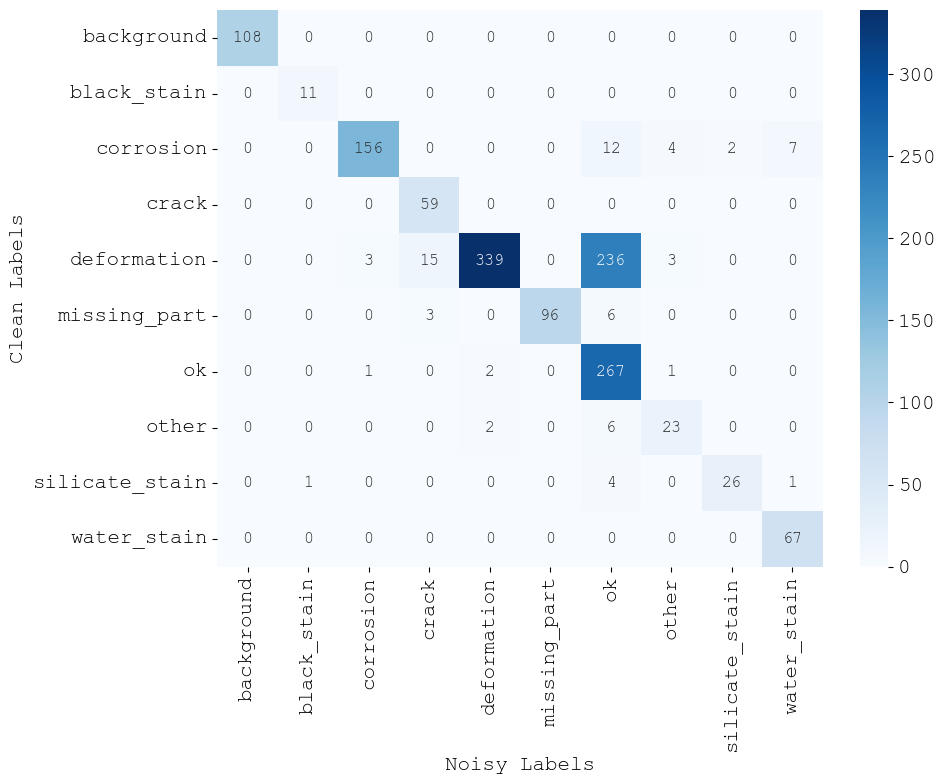

Confusion Matrix saved to ./noise_estimation/confusion_matrix.png

Total images matched: 1461


In [77]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Courier New",
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "figure.titlesize": 15
})

# Get the confusion matrix
cm = confusion_matrix(merged_labels['label_clean'], merged_labels['label_noisy'])

# Get unique labels
labels = sorted(merged_labels['label_clean'].unique())

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Noisy Labels')
plt.ylabel('Clean Labels')
plt.tight_layout()
plt.savefig(os.path.join(artifacts_path, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Confusion Matrix saved to {os.path.join(artifacts_path, 'confusion_matrix.png')}")
print(f"\nTotal images matched: {len(merged_labels)}")

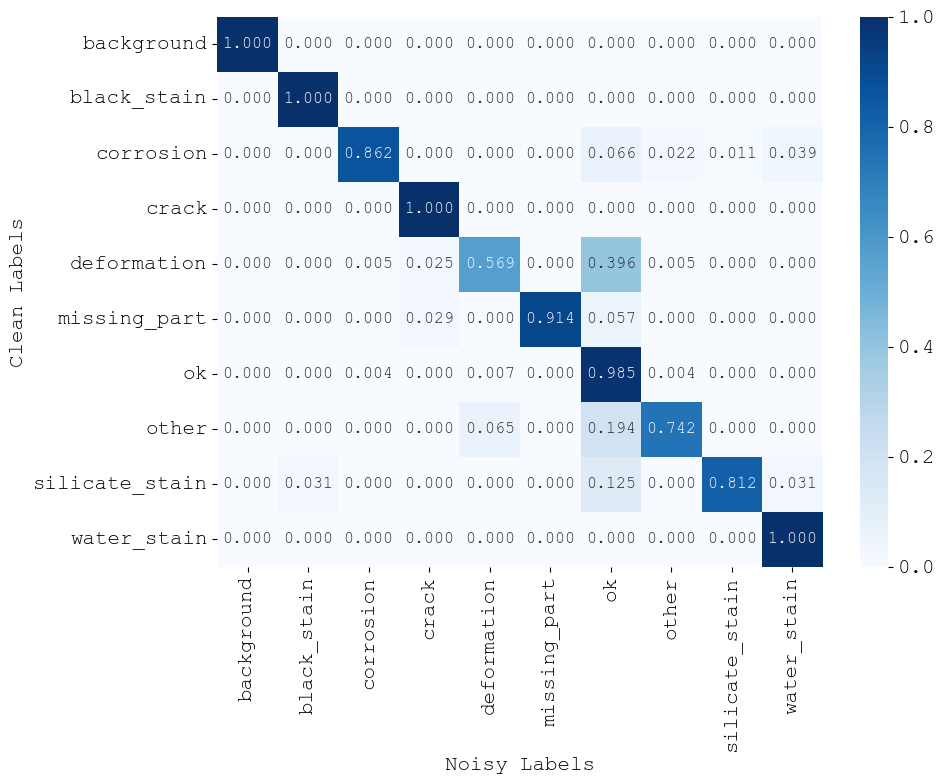

Confusion Matrix saved to ./noise_estimation/confusion_matrix_normalized.png

Total images matched: 1461


In [78]:
# Get the confusion matrix
cm_n = confusion_matrix(merged_labels['label_clean'], merged_labels['label_noisy'], normalize='true')

# Get unique labels
labels = sorted(merged_labels['label_clean'].unique())

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_n, annot=True, fmt='.3f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Noisy Labels')
plt.ylabel('Clean Labels')
plt.tight_layout()
plt.savefig(os.path.join(artifacts_path, 'confusion_matrix_normalized.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Confusion Matrix saved to {os.path.join(artifacts_path, 'confusion_matrix_normalized.png')}")
print(f"\nTotal images matched: {len(merged_labels)}")

In [79]:
import torch
from pathlib import Path
from datetime import datetime

def save_noise_matrix(path: str, T: torch.Tensor, class_names=None, extra=None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    payload = {
        "T": T.detach().float().cpu(),          # [C, C], row-stochastic
        "convention": "T[i,j]=P(y_noisy=j | y_clean=i)",
        "normalized": "rowsum=1",
        "class_names": class_names,             # list[str] in the exact index order
        "created_at": datetime.now().isoformat(),
        "extra": extra or {},                   # anything: dataset, split, estimator settings, seed, etc.
    }
    torch.save(payload, path)

save_noise_matrix(os.path.join(artifacts_path, 'noise_matrix.pt'), torch.tensor(cm_n), class_names=labels)